In [120]:
# Bài toán: Dự đoán Khả năng Nợ xấu (Credit Scoring)
import pandas as pd 
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [121]:
# 1. Load dữ liệu
path = 'F:/MachineLearning Tutorial/datasets/GiveMeSomeCredit/cs-training.csv'
df = pd.read_csv(path)

df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

df = df[(df['age'] > 18) & (df['age'] < 100)]

# Tách Feature (X) và Target (y)
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

# Chia tập dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [122]:
# 2. PREPROCESSING (Tránh Data Leakage)
# Điền giá trị thiếu dựa trên tập Train
train_median = X_train.median()
X_train.fillna(train_median, inplace=True)
X_test.fillna(train_median, inplace=True)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [123]:
# 3. TRAINING MODEL
# ==========================================
model = LogisticRegression(
    C=1.0, 
    penalty='l2', 
    solver='liblinear', 
    class_weight='balanced' 
)
model.fit(X_train_scaled, y_train)

# Dự đoán
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

F:\temp\ipykernel_7064\1784747354.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coef", y="Feature", data=coef_df, palette="viridis")


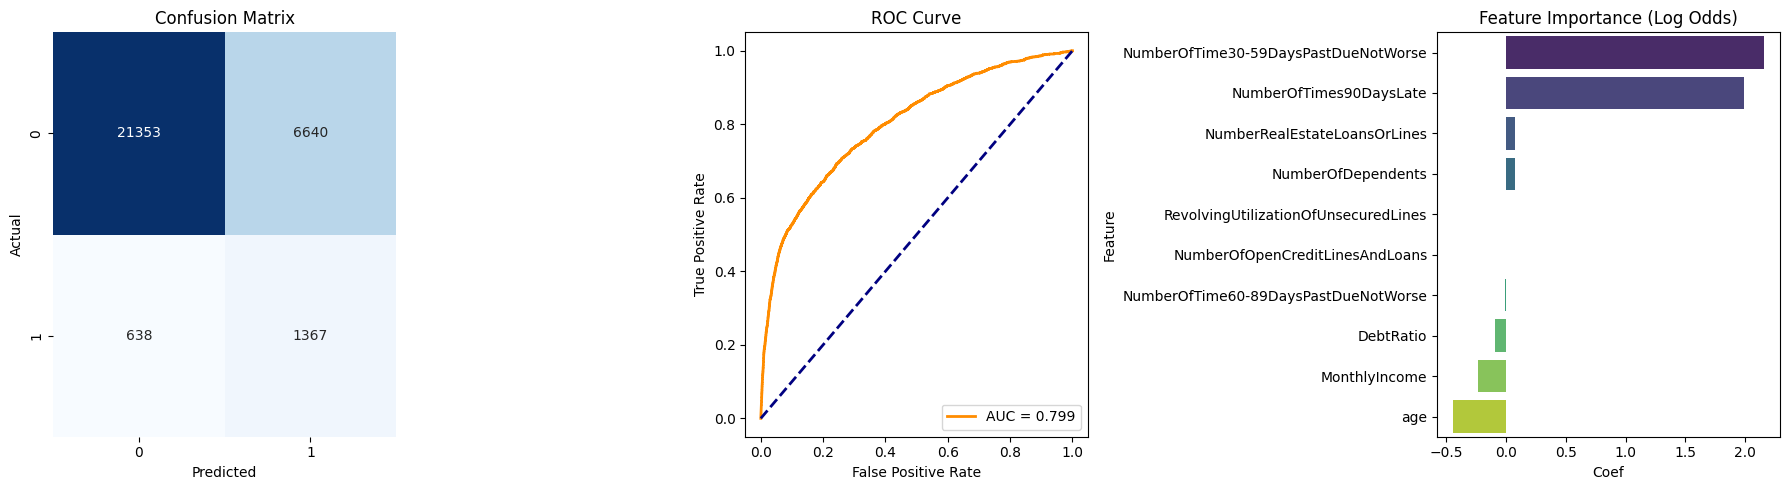

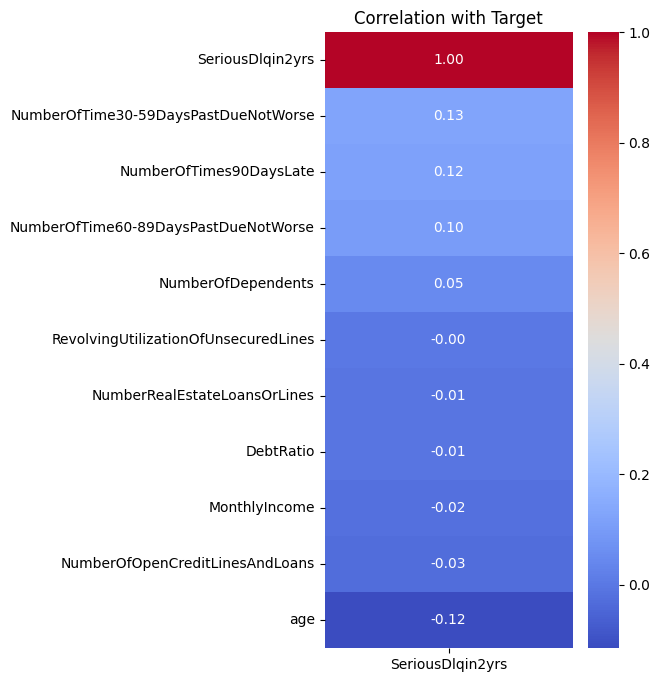

In [124]:
# 4. VISUALIZATION (Trực quan hóa)
plt.figure(figsize=(18, 5))

# Biểu đồ 1: Confusion Matrix
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Biểu đồ 2: ROC Curve
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}", color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# Biểu đồ 3: Feature Importance 
plt.subplot(1, 3, 3)
coef_df = pd.DataFrame({"Feature": X.columns, "Coef": model.coef_[0]})
coef_df = coef_df.sort_values(by="Coef", ascending=False)
sns.barplot(x="Coef", y="Feature", data=coef_df, palette="viridis")
plt.title("Feature Importance (Log Odds)")

plt.tight_layout()
plt.show()

# Biểu đồ 4: Correlation Heatmap
plt.figure(figsize=(4, 8))
corr_with_target = df.corr()[['SeriousDlqin2yrs']].sort_values(by='SeriousDlqin2yrs', ascending=False)
sns.heatmap(corr_with_target, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation with Target")
plt.show()

In [ ]:
# 5. EVALUATION & SAVE

print("\n--- PHÂN TÍCH CHI TIẾT ---")
print(classification_report(y_test, y_pred))

# Lưu Model và Scaler
# joblib.dump(model, "/logistic_model.pkl")
# joblib.dump(scaler, "scaler.pkl")
# print("Đã lưu model thành công!")

# Nếu muốn lưu model, hãy bỏ comment 3 dòng trên và chạy lại.


--- PHÂN TÍCH CHI TIẾT ---
              precision    recall  f1-score   support

           0       0.97      0.76      0.85     27993
           1       0.17      0.68      0.27      2005

    accuracy                           0.76     29998
   macro avg       0.57      0.72      0.56     29998
weighted avg       0.92      0.76      0.82     29998

